## Tehnike za rad sa nebalansiranim skupovima podataka

Za skup podataka kažemo da je **nebalansiran** ukoliko ima značajno više instanci jedne klase u odnosu na drugu klasu (ili klase). U realnim problemima klasifikacije vrlo često su podaci sa kojima se raspolaže u znatnoj meri nebalansirani usled retkosti fenomena koji se modeluje. Na primer, kod bankarskih transakcija samo jedan mali procenat transakcija nije regularan i podleže zakonskim procedurama. Slično, kada su retke bolesti u pitanju, mali je broj pacijenata za koje su mogu pronaći medicinski podaci. Međutim, postoje i scenariji kada je nebalansiranost podatak posledica lošeg odabira uzorka. Na primer, u anketi je ispitivana većinski mlađa populacija, a ne opšte mnjenje.

Kako ne bismo dobili model koji sve/većinu instanci klasifikuje u većinsku klasu i koji samim tim nije upotrebljiv, potrebno je da na neki način smanjimo uticaj nebalansiranosti klasa na proces učenje modela. Postoje različite tehnike kojima se to može postići.

**Eliminacija instanci većinske klase (eng. *under-sampling*)** $\hspace{0.2cm}$ Ukoliko je na raspolaganju dovoljan broj instanci manjinske klase, može se izdvojiti isto toliko instanci većinske klase i obučavati model na ovako dobijenom balansiranom skupu. Izbor instanci većinske klase može da bude nasumičan.

**Generisanje novih instanci manjinske klase (eng. *over-sampling*)** $\hspace{0.2cm}$ Ukoliko nije na raspolaganju dovoljan broj instanci manjinske klase, može se probati sa generisanjem novih instanci istih/veoma sličnih vrednosti atributa kao postojeće instance. Postoje različite tehnike koje na različite načine simuliraju generisanje instanci iz iste raspodele.

<img src="img/under_and_over_sampling.png" width=700>

Oba pomenuta pristupa imaju svoje prednosti i mane. Eliminisanjem instanci moze doći do gubitka važnih informacija, dok se generisanjem novih instanci povećava rizik od preprilagodjavanja (kada se multipliciraju postojeće instance) ili može doći do ubacivanja dodatnog šuma u skup podataka (kada se generisu u potpunosti nove instance). Takođe, u oba slučaja nasumičan izbor može biti pristrasan i može uticati na performanse klasifikatora. 

**Pridruživanje različitih težina klasama (eng. class-weighting)** $\hspace{0.2cm}$ U osnovi ovog pristupa je ideja da se različito penalizuju greške modela na instancama manjinske u odnosu na instance većinske klasi. Veće vrednosti pridruženih težina instancama manjihske klase ukazuju modelu da obrati 'više pažnje' na njih prilikom obučavanja.

**Ansambli** $\hspace{0.2cm}$ U ovom pristupu se teži da se iskoriste svi raspoloživi podaci. Koriste se sve instance manjinske klase i veći broj podskupova iste kardinalnosti instanci većinske klase. Na primer, ako imamo 400 instanci manjinske klase i 2000 instanci većinske klase, možemo napraviti 5 balansiranih skupova sa 400 instanci manjinske i 400 instanci većinske klase. Na svakom od ovih skupova se može obučiti poseban klasifikator. Kada je potrebno klasifikovati novu instancu koriste se svi klasifikatori i primenjuje se npr. *princip većinskog glasanja* - instanca se pridružuje klasi za koju najveći broj klasifikatora 'glasa'. Kao ocena ovakvog skupa modela (ansambla) može se uzeti npr. prosek ocena pojedinačnih klasifikatora.

U svim prethodno navedenim pristupima može se probati i sa različitim razmerama manjinske i većinske klase, npr 1:2, 1:3, 2:3 i slučno. Na taj način se ne eliminiše u potpunosti, ali se značajno ublažava nebalansiranost klasa, pritom umanjujući negativne strane ovih tehnika na učenje modela.

## Biblioteka imbalanced-learn ⚖️

Koristićemo biblioteku za rad sa nebalansiranim klasama: [imblearn](https://imbalanced-learn.org/stable/).
U okviru ove sveske biće prikazane sledeće tehnike:
   1. Over-sampling
        - <code>RandomOverSampler</code>
        - <code>SMOTE</code>
   2. Under-Sampling
        - <code>RandomUnderSampling</code>
        - <code>NearMiss</code>
        - <code>CondenseNearestNeighnour</code>
   3. Kombinacija over i under-sampling-a
        - <code>SMOTEENN</code>
   4. Tehnike zasnovane na ansamblima
        - <code>BalancedRandomForestClassifier</code>

In [1]:
# instaliranje biblioteke
# !pip install imblearn

### Učitavanje i analiza skupa podataka
Problem koji rešavamo je klasifikacija mase na _Benignu_ (-1) i _Malignu_ (1) na osnovu mamografskog rezultata. Skup podataka sa kojim ćemo raditi je _mammography_ koji je dostupan u okviru *imbalanced-learn* biblioteke.

In [2]:
from imblearn.datasets import fetch_datasets

In [3]:
data = fetch_datasets()['mammography']              #fetch_datasets() ucitava citavu kolekciju skupova podataka

Da bismo mogli da koristimo funkcije i metode Pandas biblioteke, preći ćemo na <code>DataFrame</code> strukture podataka.

In [4]:
import pandas as pd

In [5]:
X = pd.DataFrame(data.data)
Y = pd.Series(data.target)

Dimenzije skupa podataka:

In [6]:
X.shape

(11183, 6)

Deskriptivne statistike ulaznih atributa:

In [7]:
X.describe()

,0,1,2,3,4,5
count,1.118300e+04,1.118300e+04,1.118300e+04,1.118300e+04,1.118300e+04,1.118300e+04
mean,1.096536e-10,1.297595e-09,5.698113e-10,-2.435706e-09,-1.120680e-09,1.459483e-09
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-7.844148e-01,-4.701953e-01,-5.916315e-01,-8.595525e-01,-3.778657e-01,-9.457232e-01
25%,-7.844148e-01,-4.701953e-01,-5.916315e-01,-8.595525e-01,-3.778657e-01,-9.457232e-01
50%,-1.085769e-01,-3.949941e-01,-2.309790e-01,-8.595525e-01,-3.778657e-01,-9.457232e-01
75%,3.139489e-01,-7.649473e-02,2.198366e-01,8.202077e-01,-3.778657e-01,1.016613e+00
max,3.150844e+01,5.085849e+00,2.947777e+01,9.591164e+00,2.361712e+01,1.949027e+00


❔ Šta možemo zaključiti o podacima? (Standardizovani su)

Grafički prikaz odnosa broja instanci po klasama.

In [8]:
from matplotlib import pyplot as plt

In [9]:
Y.value_counts()

-1    10923
 1      260
dtype: int64

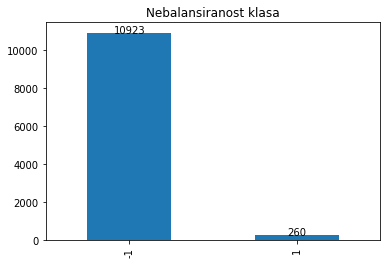

In [10]:
plt.title('Nebalansiranost klasa') 
Y.value_counts().plot.bar()

for class_label, class_count in enumerate(Y.value_counts().values):  
    #ispisivanje broja iznad stubića: plt.text(x_position, y_position, text_string)
    plt.text(class_label, class_count, str(class_count), ha='center')   

Podela na trening i test skup.

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, stratify=Y, test_size=0.25, random_state=42)

## Metrike za evaluaciju modela na nebalansiranim skupovima podataka

U situacijama kada imamo izrazito nebalansirane klase, ne možemo da koristimo _accuracy_ za evaluaciju modela. Npr. ako 99% instanci koje pripadaju većinskoj klasi. Naš model može klasifikovati sve instance u većinsku (što bi bio jako loš model), ali bi _accuracy_ bila 0,99 (što bi signaliziralo da je model jako dobar).

Izveštaj klasifikacije za nebalansirane podatke (<code>classification_report_imbalanced</code>) u okviru sklearn-a prikazuje sledeće *state-of-the-art* metrike za ocenu modela obučavanih na nebalansiranim skupovima podataka: 
- preciznost (eng. *precision*)
- odziv (eng. *recall*) ili osetljivost (eng. *sensitivity*)
- specifičnost (eng. *specificity*)
- geometrijski prosek osetljivosti i specifičnosti (eng. *geometric mean of class-wise sensitivity*)
$$G\text{-}mean = \sqrt{Sensitivity \cdot Specificity}$$
- indeks balansirane tačnosti (eng. *index balanced accuracy*) 
$$IBA_\alpha = (1 + \alpha \cdot Dominance) \cdot Metric$$

    * $Metric$ je tipično $G\text{-}mean^{2}$ ali može biti i bilo koja druga metrika
    * $Dominance = Recall - Specificity$
    * $\alpha$ je težinski koeficijent (default 0.1) kojim se podešava uticaj $Dominance$ faktora

[Literatura za detaljnije upoznavanje sa navedenim metrikama.](https://imbalanced-learn.org/dev/references/generated/imblearn.metrics.classification_report_imbalanced.html)

### Pomoćna funkcija za izveštaj klasifikacije

Pošto ćemo trenirate više modela, definišemo pomoćnu funkciju za ispisivanje izveštaja klasifikacije.

In [13]:
# !pip install termcolor
from termcolor import colored  
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import confusion_matrix       

In [14]:
def report_imbalanced(model, x, y, text = "training"):
    y_pred = model.predict(x)
    
    print(colored("Classification report for model {} on {} data".format(type(model).__name__, text), "green"))
    print("---------------------------------------------------------------------------------")
    print(classification_report_imbalanced(y, y_pred))
    print("---------------------------------------------------------------------------------")
    
    print(colored("Confusion matrix for model {} on {} data ".format(type(model).__name__, text), "green"))
    print("---------------------------------------------------------------------------------")
    print(pd.DataFrame(confusion_matrix(y, y_pred), columns=['B', 'M'], index=['B', 'M']))
    print("---------------------------------------------------------------------------------")

## 0. Baseline model

Koristićemo model stabla odlučivanja sa hiperparametrima <code>max_depth=7</code>, <code>min_samples_split=25</code>, <code>criterion='gini'</code>. 

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
baseline_model = DecisionTreeClassifier(max_depth=7, min_samples_split=25, criterion='gini')

In [17]:
baseline_model.fit(X_train, Y_train)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=25,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [18]:
report_imbalanced(baseline_model, X_train, Y_train, "training")

Classification report for model DecisionTreeClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       0.99      1.00      0.61      0.99      0.78      0.63      8192
          1       0.88      0.61      1.00      0.72      0.78      0.59       195

avg / total       0.99      0.99      0.62      0.99      0.78      0.63      8387

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on training data 
---------------------------------------------------------------------------------
      B    M
B  8176   16
M    76  119
---------------------------------------------------------------------------------


In [19]:
report_imbalanced(baseline_model, X_test, Y_test, "test")

Classification report for model DecisionTreeClassifier on test data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       0.99      0.99      0.51      0.99      0.71      0.53      2731
          1       0.69      0.51      0.99      0.58      0.71      0.48        65

avg / total       0.98      0.98      0.52      0.98      0.71      0.53      2796

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on test data 
---------------------------------------------------------------------------------
      B   M
B  2716  15
M    32  33
---------------------------------------------------------------------------------


📚 Domaći: Isprobati tehniku pridruživanja težina klasama postavljanjem parametra modela <code>class_weight</code> na "balanced". Da li se dobija bolji model?

### Pomoćna funkcija za vizuelizaciju 

Pošto ćemo isprobati više resampling tehnika, definišemo pomoćnu funkciju za vizuelizaciju skupa podataka nakon resampling-a. Kako bismo mogli da vizuelizujemo skup podataka, primenićemo *PCA* za redukciju na dve dimenzije.

In [20]:
from sklearn.decomposition import PCA

In [21]:
def visualize(X_original, X_resampled, Y_original, Y_resampled):    
    pca = PCA(n_components=2)
    pca.fit(X_original)
    
    X_original_pca = pca.transform(X_original)
    X_resampled_pca = pca.transform(X_resampled) 
    
    X_stacked = [X_original_pca, X_resampled_pca]
    Y_stacked = [Y_original, Y_resampled]
    
    fig = plt.figure(figsize=(10, 5))
    
    for i in range(2):
        ax = plt.subplot(1, 2, i+1)
        colors = ['blue' if y == -1 else 'red' for y in Y_stacked[i]]
        plt.scatter(X_stacked[i][:, 0], X_stacked[i][:, 1], c=colors, alpha=0.5)
        plt.title('{} resampling'.format("After" if i else "Before"))
    plt.show()

Nakon primene svake od tehnika rada sa nebalansiranim klasama, primenjujemo isti model.

📚 Domaći: Popraviti korišćeni model. Probati i sa ostalim modelima koje smo koristili na vezbama. Koji se pokazao kao najbolji za rešavanje ovog problema klasifikacije? 

### Data leakage ☠️
Da li resampling vršimo pre ili posle podele na trening i test? Posle!! Zašto?

## 1. Over-sampling

Jedan način balansiranja skupa je generisanje novih instanci uzorkovanjem manjinske klase.

### 1.1. RandomOverSampler

Naivna strategija je da generišemo nove instance slučajnim uzorkovanjem sa ponavljanjem iz postojećeg skupa podataka. Uzorkovanje se vrši iz manjinske klase sa ponavljanjem.

In [22]:
from imblearn.over_sampling import RandomOverSampler

Parametrom <code>sampling_strategy</code> utiče se na željeni odnos broja instanci manjinske i većinske klase nakon resampling-a.

In [23]:
ros = RandomOverSampler(sampling_strategy='minority',random_state=0)

In [24]:
X_train_resampled, Y_train_resampled = ros.fit_resample(X_train, Y_train) 

Broj instanci pre i posle resampling-a:

In [25]:
Y_train.value_counts()

-1    8192
 1     195
dtype: int64

In [26]:
pd.Series(Y_train_resampled).value_counts()

-1    8192
 1    8192
dtype: int64

Vizuelizacija skupa podataka pre i posle resampling-a.

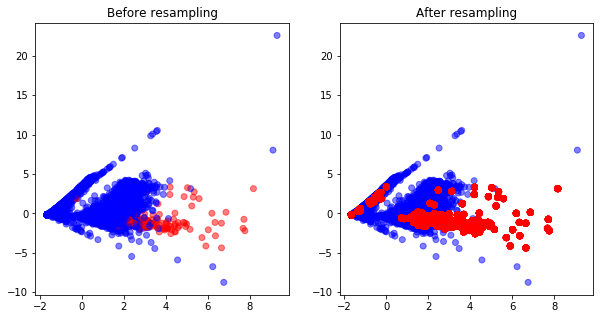

In [27]:
visualize(X_train, X_train_resampled, Y_train, Y_train_resampled)

Na osnovu grafika možemo da vidimo glavni nedostatak ove tehnike. Broj instanci u većinskoj klasi je 40 puta veći od broja instanci u manjinskoj. Kako vršimo slučajno uzorkovanje sa ponavljanjem, svaka od instanci će se ponoviti veći broj puta. Dakle, na ovaj način ne dobijamo nove informacije o manjinskoj klasi, već samo povećavamo njihov broj.

Obučavanje modela na novodobijenom skupu podataka i izveštaj klasifikacije.

In [28]:
model_ros = DecisionTreeClassifier(max_depth=7, min_samples_split=25, criterion='gini')

In [29]:
model_ros.fit(X_train_resampled, Y_train_resampled)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=25,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [30]:
report_imbalanced(model_ros, X_test, Y_test)

Classification report for model DecisionTreeClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       1.00      0.97      0.82      0.98      0.89      0.80      2731
          1       0.39      0.82      0.97      0.53      0.89      0.78        65

avg / total       0.98      0.97      0.82      0.97      0.89      0.80      2796

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on training data 
---------------------------------------------------------------------------------
      B   M
B  2648  83
M    12  53
---------------------------------------------------------------------------------


### 1.2. SMOTE -  Synthetic Minority Over-sampling Technique

Dok prethodnog pristupa gde se vrši dupliranje originalnih instanci, *SMOTE* algoritmom se **generišu nove instance interpolacijom**.

**SMOTE** (*Syntetic Minority Over-sampling Technique*) je jedan od najpoznatijih algoritama za generisanje sintetickih instanci. Za svaku instancu manjinske klase posmatra se okolina *k* najblizih suseda (*k* - parametar algoritma), takođe pripadnika manjinske klase. Duž pravca koji spajaju uočenu instancu i njene susede (sve ili neke od njih, u zavisnosti od potrebe) interpoliraju se nove instance. S obzirom da nema eksplicitnog ponavljanja instanci, ublažena je mogućnost preprilagodjavanja. Mana ove tehnike je u tome može uvesti dodatni šum u skup podataka ukoliko se u okolinama koje se posmatraju nalaze i instance većinske klase.

Dodatna literatura: [originalni rad u kome je predložen SMOTE](https://arxiv.org/pdf/1106.1813.pdf).

#### Kratko objašnjenje SMOTE

Zamislimo da imamo narednu situaciju i želimo da primenimo SMOTE algoritam:

<img src="img/smote1.png" width="70%">

*SMOTE* sintetiše nove instance između postojećih (originalnih) instanci manjinske klase. Možemo zamisliti kao povlačenje linija između postojećih instanci - kao na slici ispod.

<img src="img/smote2.png" width="70%">

Jedan od parametara koji je bitan za *SMOTE* algoritam je **k_neighbors**, koji označava koliko najbližih suseda razmatramo za svaku instancu manjinske klase.

Na primer, za **k_neighbors = 1**: 
<img src="img/smote3.png" width="70%">

Dakle, posmatramo najbližeg suseda, i generišemo instancu na liniji između te dve tačke. 

Uopšteno, *SMOTE* algoritam iterira kroz postojeće instance originalnog skupa. U svakoj iteraciji, jedan od *k* najbližih suseda se izabere i sintetiše se nova instanca negde između originalne instance i izabranog suseda.

In [31]:
from imblearn.over_sampling import SMOTE

In [32]:
smote = SMOTE(k_neighbors=10, sampling_strategy=1/5, random_state=17)

In [33]:
X_train_resampled_smote, Y_train_resampled_smote = smote.fit_resample(X_train, Y_train) 

Vizuelizacija skupa podataka pre i posle resampling-a.

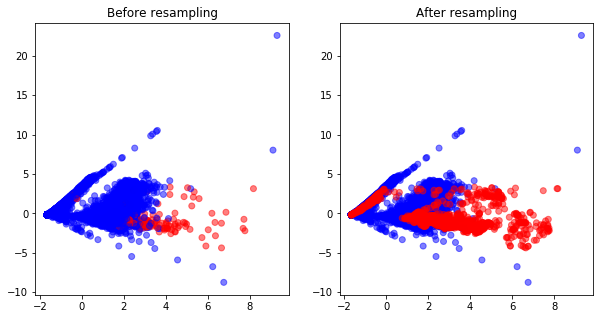

In [34]:
visualize(X_train, X_train_resampled_smote, Y_train, Y_train_resampled_smote)

Vidimo da je sada gušće popunjen prostor instancama. Dakle, dodali smo nove informacije o manjinskoj klasi, ali smo potencijalno uneli preveliki šum u naše podatke. 

❔ Da li je ova tehnika osetljiva na autlajere?

Obučavanje modela na novodobijenom skupu podataka i izveštaj klasifikacije.

In [35]:
model_smote = DecisionTreeClassifier(max_depth=7, min_samples_split=25, criterion='gini')

In [36]:
model_smote.fit(X_train_resampled_smote, Y_train_resampled_smote)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=25,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [37]:
report_imbalanced(model_smote, X_test, Y_test)

Classification report for model DecisionTreeClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       0.99      0.98      0.75      0.99      0.86      0.76      2731
          1       0.51      0.75      0.98      0.61      0.86      0.72        65

avg / total       0.98      0.98      0.76      0.98      0.86      0.76      2796

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on training data 
---------------------------------------------------------------------------------
      B   M
B  2684  47
M    16  49
---------------------------------------------------------------------------------


## 2. Under-sampling

Drugi način da balansiramo skup podataka je da smanjimo broj instanci većinske klase - opet uzorkovanjem.

### 2.1. RandomUnderSampler

Naivna varijanta je da izvršimo slučajno uzorkovanje iz većinske klase. Analogno over-sampling tehnici, samo se na slučajan način iz većinske klase biraju instance koje će biti izbačene.

In [38]:
from imblearn.under_sampling import RandomUnderSampler

In [39]:
rus = RandomUnderSampler(sampling_strategy=1/3, random_state=7)

In [40]:
X_train_resampled, Y_train_resampled = rus.fit_resample(X_train, Y_train) 

Broj instanci pre i posle resampling-a:

In [41]:
Y_train.value_counts()

-1    8192
 1     195
dtype: int64

In [42]:
pd.Series(Y_train_resampled).value_counts()

-1    585
 1    195
dtype: int64

Vizuelizacija skupa podataka pre i posle resampling-a.

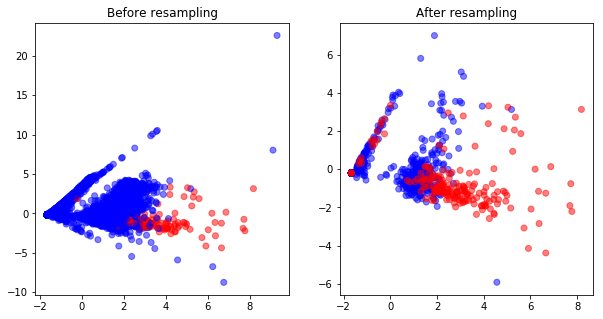

In [43]:
visualize(X_train, X_train_resampled, Y_train, Y_train_resampled)

Jednostavna tehnika, kojom smo izbalansirali klase, ali potencijalno izgubili bitne informacije o većinskoj klasi.

Obučavanje modela na novodobijenom skupu podataka i izveštaj klasifikacije.

In [44]:
model_rus = DecisionTreeClassifier(max_depth=7, min_samples_split=25, criterion='gini')

In [45]:
model_rus.fit(X_train_resampled, Y_train_resampled)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=25,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [46]:
report_imbalanced(model_rus, X_test, Y_test)

Classification report for model DecisionTreeClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       1.00      0.91      0.88      0.95      0.90      0.80      2731
          1       0.20      0.88      0.91      0.32      0.90      0.80        65

avg / total       0.98      0.91      0.88      0.94      0.90      0.80      2796

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on training data 
---------------------------------------------------------------------------------
      B    M
B  2496  235
M     8   57
---------------------------------------------------------------------------------


### 2.2. NearMiss - version 1,  2 & 3

*Near-Miss* algoritam, umesto nasumičnog odabira, bira instance većinske klase koje će zadržati prema njihovom rastojanju u odnosu na instance manjinske klase. Ovakvim pristupom pokušava se umanjiti gubitak relevantnih informacija o većinskoj klasi, odnosno o odnosu između instanci većinske i manjinske klase. Algoritam se zasniva na algoritmu najbližeg suseda i ima nekoliko varijacija.

<img src="img/NearMiss.png" width=600>

- NearMiss-1 - bira one instance većinske klase koje imaju najmanje prosečno rastojanje od njima _K_ **najbližih** instanci manjinske klase 
- NearMiss-2 - bira one instance većinske klase koje imaju najmanje prosečno rastojanje od njima _K_ **najdaljih** instanci manjinske klase
- NearMiss-3 - algoritam se sastoji iz dva koraka: prvo se za svaku instancu manjinske klase čuva njoj _K_ najbliži suseda većinske klase, dok se preostale instance većinske klase odbacuju, a zatim se od zadržanih instanci većinske klase biraju samo one koje imaju najveće prosečno rastojanje njima _K_ najbližih suseda

Predstavljaju jedne od najboljih under-sampling tehnika.
Sve tri verzije su osetljive na šum, od čega je NearMiss-1 najosetljiviji, a NearMiss-3 najmanje.


In [47]:
from imblearn.under_sampling import NearMiss

### NearMiss-1

In [48]:
nm1 = NearMiss(version=1, n_neighbors=20)

In [49]:
X_train_resampled_nm1, Y_train_resampled_nm1 = nm1.fit_resample(X_train, Y_train) 

Obučavanje modela na novodobijenom skupu podataka i izveštaj klasifikacije.

In [50]:
model_nm1 = DecisionTreeClassifier(max_depth=7, min_samples_split=25, criterion='gini')

In [51]:
model_nm1.fit(X_train_resampled, Y_train_resampled)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=25,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [52]:
report_imbalanced(model_nm1, X_test, Y_test)

Classification report for model DecisionTreeClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       1.00      0.91      0.88      0.95      0.90      0.80      2731
          1       0.20      0.88      0.91      0.32      0.90      0.80        65

avg / total       0.98      0.91      0.88      0.94      0.90      0.80      2796

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on training data 
---------------------------------------------------------------------------------
      B    M
B  2496  235
M     8   57
---------------------------------------------------------------------------------


### NearMiss-2

In [53]:
nm2 = NearMiss(version=2, n_neighbors=20)

In [54]:
X_train_resampled_nm2, Y_train_resampled_nm2 = nm2.fit_resample(X_train, Y_train) 

Obučavanje modela na novodobijenom skupu podataka i izveštaj klasifikacije.

In [55]:
model_nm2 = DecisionTreeClassifier(max_depth=7, min_samples_split=25, criterion='gini')

In [56]:
model_nm2.fit(X_train_resampled, Y_train_resampled)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=25,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [57]:
report_imbalanced(model_nm2, X_test, Y_test)

Classification report for model DecisionTreeClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       1.00      0.91      0.88      0.95      0.90      0.80      2731
          1       0.20      0.88      0.91      0.32      0.90      0.80        65

avg / total       0.98      0.91      0.88      0.94      0.90      0.80      2796

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on training data 
---------------------------------------------------------------------------------
      B    M
B  2496  235
M     8   57
---------------------------------------------------------------------------------


### NearMiss-3

In [58]:
nm3 = NearMiss(version=3, n_neighbors=20)

In [59]:
X_train_resampled_nm3, Y_train_resampled_nm3 = nm3.fit_resample(X_train, Y_train) 

Obučavanje modela na novodobijenom skupu podataka i izveštaj klasifikacije.

In [60]:
model_nm3 = DecisionTreeClassifier(max_depth=7, min_samples_split=25, criterion='gini')

In [61]:
model_nm3.fit(X_train_resampled, Y_train_resampled)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=25,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [62]:
report_imbalanced(model_nm3, X_test, Y_test)

Classification report for model DecisionTreeClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       1.00      0.91      0.88      0.95      0.90      0.80      2731
          1       0.20      0.88      0.91      0.32      0.90      0.80        65

avg / total       0.98      0.91      0.88      0.94      0.90      0.80      2796

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on training data 
---------------------------------------------------------------------------------
      B    M
B  2496  235
M     8   57
---------------------------------------------------------------------------------


#### Uporedni prikaz skupa podataka pre i posle resampling-a za tri varijante NearMiss tehnike

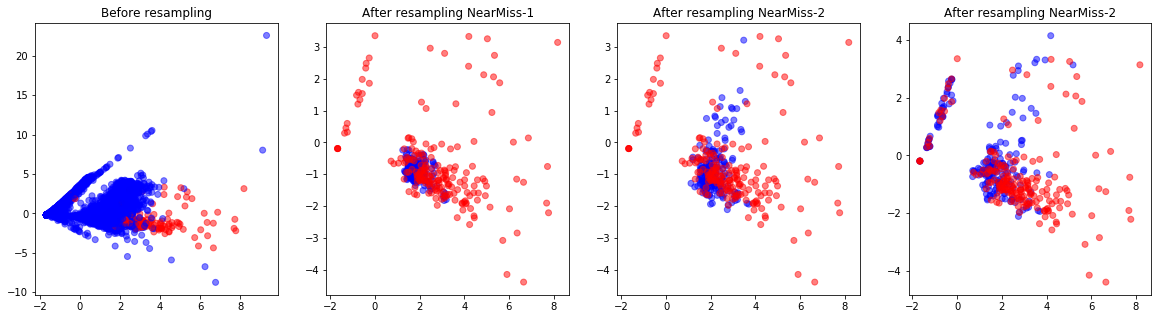

In [63]:
pca = PCA(n_components=2)
pca.fit(X_train)
    
Xs = [pca.transform(X_train), pca.transform(X_train_resampled_nm1), 
      pca.transform(X_train_resampled_nm2), pca.transform(X_train_resampled_nm3)]
Ys = [Y_train, Y_train_resampled_nm1, Y_train_resampled_nm2, Y_train_resampled_nm3]    

titles = ['Before resampling', 'After resampling NearMiss-1', 
          'After resampling NearMiss-2', 'After resampling NearMiss-2']   

fig = plt.figure(figsize=(20, 5))
    
for i in range(4):
    ax = plt.subplot(1, 4, i+1)
    colors = ['blue' if y == -1 else 'red' for y in Ys[i]]
    plt.scatter(Xs[i][:, 0], Xs[i][:, 1], c=colors, alpha=0.5)
    plt.title(titles[i])
plt.show()

### 2.3. CondenseNearestNeighbour

<code>CondensedNearestNeighbour</code> koristi 1-najbliži-sused pravilo da iterativno odluči koje instance iz većinske klase treba ukloniti. 

**Algoritam**: Neka je *C* skup instanci koje će se zadržati, a *S* skup kandidata za eliminisanje 
1. Ubaciti sve instance iz manjinske klase u skup _C_.
2. Dodati slučajno odabranu instancu iz većinske klase u _C_ i sve ostale instance u skup _S_.
3. Iterirati kroz S, instancu po instancu i klasifikovati svaku na osnovu pravila 1-suseda.
4. Ako je instanca netačno klasifikovana, ubaciti je u _C_.
5. Ponavljati postupak sve dok postoje inastance koje se mogu dodati.

I ova tehnika je osetljiva na šum i dodaje šum u podatke.

In [64]:
from imblearn.under_sampling import CondensedNearestNeighbour

In [65]:
cnn = CondensedNearestNeighbour(random_state=0, n_neighbors=10, sampling_strategy='majority')

In [66]:
X_train_resampled, Y_train_resampled = cnn.fit_resample(X_train, Y_train) 

Vizuelizacija skupa podataka pre i posle resampling-a.

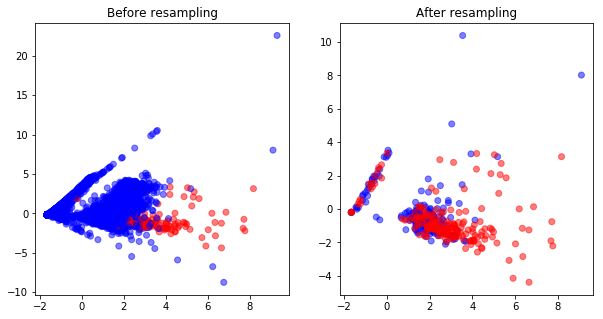

In [67]:
visualize(X_train, X_train_resampled, Y_train, Y_train_resampled)

Obučavanje modela na novodobijenom skupu podataka i izveštaj klasifikacije.

In [68]:
model_cnn = DecisionTreeClassifier(max_depth=7, min_samples_split=25, criterion='gini')

In [69]:
model_cnn.fit(X_train_resampled, Y_train_resampled)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=25,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [70]:
report_imbalanced(model_cnn, X_test, Y_test)

Classification report for model DecisionTreeClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       0.99      0.58      0.83      0.73      0.69      0.47      2731
          1       0.04      0.83      0.58      0.09      0.69      0.49        65

avg / total       0.97      0.59      0.82      0.72      0.69      0.47      2796

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on training data 
---------------------------------------------------------------------------------
      B     M
B  1585  1146
M    11    54
---------------------------------------------------------------------------------


## 3. Kombinacija over i under sampling-a 

Prethodno smo prikazali *SMOTE* algoritam, kao over-sampling tehniku, koja unosi šum u podatke interpolacijom novih tačaka između marginalnih outlajera i inlajnera. Ovaj problem se rešava čišćenjem tj. under-sampling-om podataka prethodno dobijenih over-sampling tehnikom.

*Edited nearest-neighbours* (*EEN*) predstavlja metodu čišćenja podataka nakon primene *SMOTE* algoritma (under-samping tehnika). *ENN* metoda pronalazi K najbližih suseda za svaku instancu i preverava da li je većinska klasa k najbližih instanci ista kao i klasa posmatrane instance. Ukoliko nije, posmatrana instanca i susedi se uklanjaju iz skupa. Najčešće vrednost je K = 3.

[Literatura za ENN metod čišćenja podataka nakon primene over-sampling tehnika.](https://www.inf.ufrgs.br/maslab/pergamus/pubs/balancing-training-data-for.pdf)

### SMOTEENN = SMOTE + EEN

In [71]:
from imblearn.combine import SMOTEENN

In [72]:
smoteenn = SMOTEENN(sampling_strategy=1/5, random_state=17)

In [73]:
X_train_resampled_smoteenn, Y_train_resampled_smoteenn = smoteenn.fit_resample(X_train, Y_train) 

#### Uporedni prikaz skupa podataka pre i posle resampling-a za SMOTE i SMOTEENN tehnike

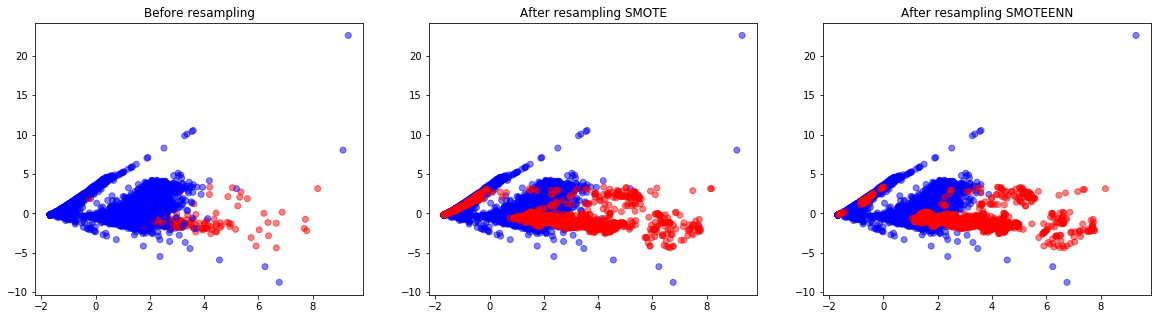

In [74]:
pca = PCA(n_components=2)
pca.fit(X_train)
    
Xs = [pca.transform(X_train), pca.transform(X_train_resampled_smote), pca.transform(X_train_resampled_smoteenn)]
Ys = [Y_train, Y_train_resampled_smote, Y_train_resampled_smoteenn]    

titles = ['Before resampling', 'After resampling SMOTE', 'After resampling SMOTEENN']   

fig = plt.figure(figsize=(20, 5))
    
for i in range(3):
    ax = plt.subplot(1, 3, i+1)
    colors = ['blue' if y == -1 else 'red' for y in Ys[i]]
    plt.scatter(Xs[i][:, 0], Xs[i][:, 1], c=colors, alpha=0.5)
    plt.title(titles[i])
plt.show()

Obučavanje modela na novodobijenom skupu podataka i izveštaj klasifikacije.

In [75]:
model_smoteenn = DecisionTreeClassifier(max_depth=7, min_samples_split=25, criterion='gini')

In [76]:
model_smoteenn.fit(X_train_resampled, Y_train_resampled)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=25,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [77]:
report_imbalanced(model_smoteenn, X_test, Y_test)

Classification report for model DecisionTreeClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       0.99      0.58      0.83      0.73      0.69      0.47      2731
          1       0.04      0.83      0.58      0.09      0.69      0.49        65

avg / total       0.97      0.59      0.82      0.72      0.69      0.47      2796

---------------------------------------------------------------------------------
Confusion matrix for model DecisionTreeClassifier on training data 
---------------------------------------------------------------------------------
      B     M
B  1585  1146
M    11    54
---------------------------------------------------------------------------------


## 4. Tehnike zasnovane na ansamblima

Pošto smo se već upoznali sa ansamblima kao primerom efikasnih modela, oni se mogu pronaći i u okviru imblearn biblioteke.

Balansirane slučajne šume vrše nasumičan under-sampling svakog podskupa skupa podataka na kome se obučavaju pojedinačni modeli (stabla odlučivanja) u ansamblu.

In [78]:
from imblearn.ensemble import BalancedRandomForestClassifier

In [79]:
model_ens = BalancedRandomForestClassifier(max_depth=6, sampling_strategy=1/3, random_state=42)

In [80]:
model_ens.fit(X_train, Y_train)

BalancedRandomForestClassifier(bootstrap=True, class_weight=None,
                criterion='gini', max_depth=6, max_features='auto',
                max_leaf_nodes=None, min_impurity_decrease=0.0,
                min_samples_leaf=2, min_samples_split=2,
                min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=1,
                oob_score=False, random_state=42, replacement=False,
                sampling_strategy=0.3333333333333333, verbose=0,
                warm_start=False)

In [81]:
report_imbalanced(model_ens, X_test, Y_test)

Classification report for model BalancedRandomForestClassifier on training data
---------------------------------------------------------------------------------
                   pre       rec       spe        f1       geo       iba       sup

         -1       1.00      0.98      0.86      0.99      0.92      0.85      2731
          1       0.46      0.86      0.98      0.60      0.92      0.83        65

avg / total       0.98      0.97      0.86      0.98      0.92      0.85      2796

---------------------------------------------------------------------------------
Confusion matrix for model BalancedRandomForestClassifier on training data 
---------------------------------------------------------------------------------
      B   M
B  2665  66
M     9  56
---------------------------------------------------------------------------------


# Poređenje modela - ROC ili PR kriva

Na slici se nalazi matrica konfuzije.

![confusion-matrix.png](img/confusion-matrix.png)

$Precision = \frac{TP}{TP+FP}$ - broj true positive kroz ukupan broj _dodeljenih_ pozitivnih.

$Recall = \frac{TP}{TP+FN}$ - broj true positive kroz ukupan broj _pravih_ pozitivnih (True positive rate). 

Napomena: Kada je u pitanju binarna klasifikacija recall se naziva i _sensitivity_.

#### PR kriva

Precision-Recall kriva prikazuje odnos između ove dve mere.

Precision sadrži informaciju koliko pozitivnih instanci smo uspeli da ispravno klasifikujemo.
Recall nam daje informaciju od svih zaista pozitivnih instanci, koliko smo ih ispravno klasifikovali.

Jasno nam je da sa rastom jedne od ovih mera, druga opada. Na primer, Ako bismo sve instance klasifikovali u TRUE klasu, naš recall bi bio 1 (sve instance čija je prava klasa TRUE su klasifikovane kao TRUE (FN = 0), ali bi precision bio jako mali (jer bi FP bio veliki). 

Dakle, želimo da napravimo odgovarajući balans između ovih mera (zavisi od problema koji se rešava).

#### Pomoćna funkcija za prikaz PR krive

In [82]:
from sklearn.metrics import precision_recall_curve, average_precision_score

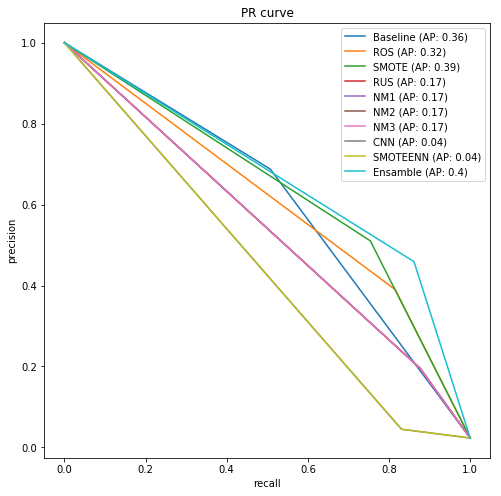

In [83]:
models = [baseline_model, model_ros, model_smote, model_rus, model_nm1, model_nm2, model_nm3, model_cnn, model_smoteenn, model_ens]
model_names = ['Baseline', 'ROS', 'SMOTE', 'RUS', "NM1", "NM2", "NM3", "CNN", "SMOTEENN", "Ensamble"]

plt.figure(figsize=(8, 8))

for model, model_name in zip(models, model_names):
    y_pred = model.predict(X_test)
    precision, recall, _ = precision_recall_curve(Y_test, model.predict(X_test))
    ap = average_precision_score(Y_test, model.predict(X_test))
    lab = model_name + " (AP: " + str(round(ap, 2)) + ")"
    plt.plot(recall, precision, label=lab)

plt.xlabel('recall')
plt.ylabel('precision')

plt.title("PR curve")
plt.legend()
plt.show()

Ostalo nam je još da prodiskutujemo kako da zaključimo koji model je najbolji, posmatrajući PR krivu.
Težimo tome da nam i preciznost i odziv budu što veći. Dakle, preferiramo krive koje su što bliže gornjem desnom uglu.

Način na koji možemo da evaluiramo modele je korišćenjem [_average precision score (AP)_.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html)
Što je AP veći to je model bolji.

#### ROC kriva

ROC kriva (eng. *Receiver Pperating Characteristic curve*) prikazuje odnos između TPR (odziv) i FPR.

$TPR = \frac{TP}{TP+FN}$

$FPR = \frac{FP}{FP+TN}$ - intuitivno, šansa da smo naš uzorak "zarazili" sa FP instancama.

#### Pomoćna funkcija za prikaz ROC krive

In [84]:
from sklearn.metrics import roc_curve, roc_auc_score

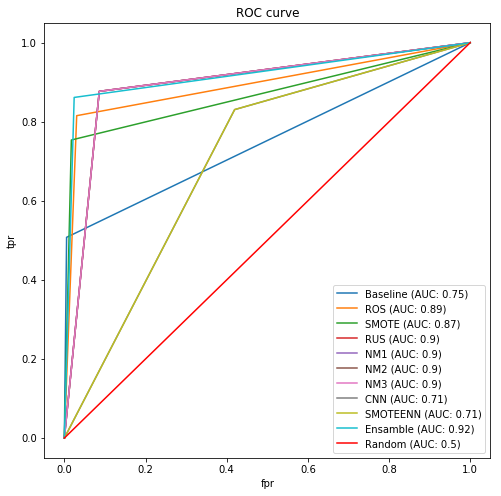

In [85]:
models = [baseline_model, model_ros, model_smote, model_rus, model_nm1, model_nm2, model_nm3, model_cnn, model_smoteenn, model_ens]
model_names = ['Baseline', 'ROS', 'SMOTE', 'RUS', "NM1", "NM2", "NM3", "CNN", "SMOTEENN", "Ensamble"]

plt.figure(figsize=(8, 8))

for model, model_name in zip(models, model_names):
    y_pred = model.predict(X_test)
    fpr,tpr, _ = roc_curve(Y_test, y_pred)
    auc = roc_auc_score(Y_test, y_pred)
    lab = model_name + " (AUC: " + str(round(auc, 2)) + ")"
    plt.plot(fpr, tpr, label=lab)

plt.xlabel('fpr')
plt.ylabel('tpr')
plt.plot([0, 1], [0, 1], label='Random (AUC: 0.5)', color='red')
plt.title("ROC curve")
plt.legend()
plt.show()

Kada posmatramo ROC krivu, model je bolji što je kriva bliža gornjem levom uglu (što veći TPR, a što manji FPR).
Za evaluciju koristimo [_area under the curve (AUC)_](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html). Što je AUC mera bliža 1, to je model bolji.

### ROC vs PR kriva

Na prvi pogled nam se krive čine jako slične. 

Neka je $Y$ prava klasa kojoj pripada instanca, a $\hat{Y}$ klasa koju model dodeli instanci (predviđena klasa).

$P(X|Y)$ - uslovna verovatnoća za događaj $X$ ako se desio događaj $Y$.

Za prikaz PR i ROC krive koristili smo 3 informacije. Za PR krivu - precision i recall, a za ROC krivu - FPR i recall. 

 Formalno: 
 
 * $Precision = P(Y = 1 | \hat{Y} = 1)$
 * $Recall/TPR = P(\hat{Y} = 1 | Y = 1)$
 * $FPR = P(\hat{Y} = 1 | Y = 0 )$

Bitno je da primetimo da je uslov kod precision predviđena klasa, dok je kod recall i FPR uslov prava klasa.

Ova osobina može imate veliki uticaj na evaluaciju ukoliko radimo sa nebalansiranim klasama ili ako veći značaj dajemo TP nego FN. 

#### Primer 
Posmatramo skup pacijenata i vršimo klasifikaciju karcinoma (100000 - negativnih i 100 pozitivnih instanci).
Imamo dva klasifikaciona modela A i B.

Nakon pokretanja oba klasifikatora, oba su ispravno klasifikovala 99/100 pacijenata. Matrice konfuzije se nalaze u nastavku.

**Matrica konfuzije za model A**

|             | real T      | real F      |
|-----------  | ----------- | ----------- |           
|predicted T  | 99          | 51          |
|predicted F  | 1           |     9949    |



**Matrica konfuzije za model B**

|             | real T      | real F      |
|-----------  | ----------- | ----------- |
|predicted T  | 99          | 901       |
|predicted F  | 1           | 9099      |


Recall za oba modela je isti -> **0.99**

FPR za modele:

FPR_A = 51/(51 + 10000) = 0.0005

FPR_B = 901/(901 + 10000) = 0.008

Ako bismo koristili ROC krivu, oba modela bi imala zanemarljive razlike i jednako dobre performanse (isti recall i skoro iste fpr).

Ali, ako bismo koristili PR krivu:

Precision_A = 99 / (99+51) = 0.66

Precision_B = 99 / (99 + 901) = 0.099

Dakle, ukoliko bismo koristili PR krivu za poređenje, sada vidimo veliku razliku! Model A ima preciznost 0.66, dok B ima < 0.1!



**Zaključak: Ako radimo sa nebalansiranim klasama, ROC kriva može dati previše optimistične evaluacije.**

Takođe, na osnovu naših modela, na grafičkim prikazima PR i ROC se može videti problem sa radom sa ROC krivom.

Na primer, AUC za BalnacedRandomForestClassifier je 0,92 (jako dobar model), ali je AP 0,17. 

####  📚 Diskusija i domaći

Posmatrajući ROC krivu imamo utisak da smo istrenirali nekoliko solidnih modela, ali PR kriva pokazuje da zapravno nijedan nije preterano dobar.

Do ovog zaključka smo mogli da dođemo i na osnovu analize matrica konfuzije. Svi modeli imaju veliki broj FP instanci (nisku preciznost).

❔ Da li je kod nekih modela došlo do preprilagođavanja?

❔ Popraviti modele, tako da daju bolje rezultate. 

### Bitna napomena za kraj

❗❗ U okviru ovih materijala, fokus je na tehnikama rada sa nebalansiranim klasama. Iz tog razloga je korišćen identičan model za klasifikaciju. Naravno, pri realnoj primeni, ne postoji osnova za korišćenje identičnog modela, sa identičnim hiper-parametrima, sa obzirom na to da različite tehnike daju različite rezultate (skupove podataka), pa bi i odbir modela i hiper-parametara trebalo da se vrši shodno ovim razlikama.